# Health Insurance Portfolio Analytics

## Executive Summary

This project analyzes a simulated health insurance portfolio to identify the main drivers of medical costs, segment members by risk, and develop a simplified risk scoring and pricing framework.

The analysis combines exploratory data analysis, business-oriented risk segmentation, portfolio concentration analysis, and a rule-based underwriting model to demonstrate how data can support insurance pricing and portfolio management decisions.

## 1. Business Context

In health insurance, companies must estimate expected medical costs per insured member in order to price policies correctly and maintain portfolio profitability.

The goal of this analysis is to simulate a simplified portfolio monitoring system that identifies:
- who drives medical costs
- how risk is distributed across the portfolio
- how pricing could be adjusted based on risk

## 2. Dataset Overview

We load the insurance dataset and inspect its structure to understand the portfolio composition.

In [1]:
import pandas as pd
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Portfolio Overview

Before performing any analysis, we assess the size of the insurance portfolio.

This provides an overview of the number of insured members and the amount of information available for each member.

In [9]:
df.shape

(1338, 7)

### Interpretation

The dataset contains **1,338 insured members** described by **7 variables**.

Each row represents one insured member, while each column contains a demographic, health-related or financial attribute used for portfolio analysis.

## 4. Data Quality Assessment

In [10]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Data Quality Interpretation

The dataset contains 1,338 insured members and 7 variables, including demographic, health-related, and geographic attributes, along with annual medical costs (charges).

All variables are complete with no missing values, making the dataset suitable for portfolio-level analysis.

The dataset can be interpreted as a simplified insurance pricing dataset where:
- Input variables represent risk factors (age, BMI, smoking status, etc.)
- The target variable (charges) represents annual medical cost per member

This structure allows us to analyze risk drivers and simulate insurance pricing behavior.

However, the dataset does not include claim frequency, medical diagnosis, or time-based information, which limits its use for more advanced actuarial modeling.

## 5. Portfolio Snapshot

We compute summary statistics to understand the overall distribution of age, BMI, and insurance costs across the portfolio.

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 5. Portfolio Size

We calculate the number of insured members and variables in the portfolio.

In [6]:
df.shape

(1338, 7)

## 6. Risk Driver Analysis

The objective of this section is to identify which member characteristics are associated with higher annual medical costs.

Understanding these risk drivers helps insurers:
- identify higher-risk segments,
- improve portfolio monitoring,
- support pricing decisions,
- prioritize future risk analyses.

We begin by evaluating the impact of smoking status on annual medical costs.

### 6.1 Smoking Status

#### Business Question

Do smokers incur higher annual medical costs than non-smokers?

#### Objective

Smoking is commonly associated with increased health risks and may lead to higher medical expenses.

By comparing average annual medical costs between smokers and non-smokers, we can assess whether smoking is a significant claims cost driver within this portfolio.

#### Analysis

We begin by examining the composition of the portfolio based on smoking status.

Understanding the proportion of smokers and non-smokers helps us evaluate the potential impact of this risk factor on the overall portfolio before comparing medical costs.

In [11]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [12]:
df["smoker"].value_counts(normalize=True) * 100

smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64

#### Interpretation

The portfolio consists of **1,338 insured members**, of which:

- **1,064 members (79.5%) are non-smokers**
- **274 members (20.5%) are smokers**

Non-smokers represent the majority of the portfolio, while smokers account for approximately one-fifth of insured members.

Although smokers form a smaller segment, they may still have a significant financial impact if their average medical costs are substantially higher than those of non-smokers. Therefore, portfolio composition should always be interpreted together with cost analysis.

In [13]:
average_cost = (
    df.groupby("smoker")["charges"]
      .mean()
      .round(2)
      .rename("Average Annual Medical Cost")
)

average_cost

smoker
no      8434.27
yes    32050.23
Name: Average Annual Medical Cost, dtype: float64

In [14]:
portfolio_average = round(df["charges"].mean(), 2)

portfolio_average

np.float64(13270.42)

In [15]:
summary = df.groupby("smoker").agg(
    Members=("smoker", "count"),
    Average_Annual_Medical_Cost=("charges", "mean")
)

summary["Average_Annual_Medical_Cost"] = summary["Average_Annual_Medical_Cost"].round(2)

summary

,Members,Average_Annual_Medical_Cost
smoker,,
no,1064,8434.27
yes,274,32050.23


#### Cost Difference

To better quantify the financial impact of smoking, we calculate how many times higher the average annual medical cost is for smokers compared with non-smokers.

In [16]:
cost_ratio = (
    summary.loc["yes", "Average_Annual_Medical_Cost"] /
    summary.loc["no", "Average_Annual_Medical_Cost"]
)

print(f"Smokers cost {cost_ratio:.2f} times more than non-smokers on average.")

Smokers cost 3.80 times more than non-smokers on average.


#### Results

The analysis shows:

- **Portfolio average annual medical cost:** €13,270.42
- **Average annual medical cost (non-smokers):** €8,434.27
- **Average annual medical cost (smokers):** €32,050.23
- **Smokers incur approximately 3.80 times higher annual medical costs than non-smokers.**

#### Interpretation

Smoking status is strongly associated with higher annual medical costs within this portfolio.

Although smokers represent only **20.5%** of insured members, their average annual medical cost is substantially higher than both the portfolio average and the average cost of non-smokers.

This suggests that smoking is an important claims cost driver and should be considered when monitoring portfolio risk.

#### Business Implication

From a portfolio management perspective, smoking status represents a valuable risk segmentation variable.

Although smokers account for only one-fifth of the portfolio, they generate substantially higher average medical costs. This indicates that monitoring the smoker segment is important for understanding portfolio risk.

In a real insurance environment, these findings could support:
- enhanced portfolio monitoring,
- more detailed risk segmentation,
- further evaluation of pricing strategies,
- targeted preventive health initiatives.

### 6.2 Risk Driver Summary

The following table summarizes the findings from each risk factor analysis.

This summary will be updated as additional variables are analyzed throughout the project.

In [18]:
risk_summary = pd.DataFrame({
    "Risk Driver": [
        "Smoking",
        "Age",
        "BMI",
        "Sex",
        "Region",
        "Children"
    ],
    "Status": [
        "Completed",
        "Pending",
        "Pending",
        "Pending",
        "Pending",
        "Pending"
    ],
    "Finding": [
        "Smokers cost 3.80× more than non-smokers",
        "",
        "",
        "",
        "",
        ""
    ]
})

risk_summary

,Risk Driver,Status,Finding
0,Smoking,Completed,Smokers cost 3.80× more than non-smokers
1,Age,Pending,
2,BMI,Pending,
3,Sex,Pending,
4,Region,Pending,
5,Children,Pending,


### 6.3 Age

#### Business Question

Do older insured members incur higher annual medical costs than younger members?

#### Objective

Age is a key demographic factor in health insurance and is often associated with differences in healthcare utilization and medical costs.

The objective of this analysis is to determine whether annual medical costs increase with age and whether age should be considered an important risk segmentation variable.

#### Analysis

To facilitate portfolio monitoring, individual ages are grouped into age bands.

Grouping members into age bands makes the results easier to interpret and reflects how insurers often monitor portfolio characteristics at an aggregate level rather than focusing on individual ages.

In [19]:
age_bins = [18, 30, 40, 50, 65]

age_labels = [
    "18–29",
    "30–39",
    "40–49",
    "50–64"
]

df["age_band"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

df[["age", "age_band"]].head(10)

,age,age_band
0,19,18–29
1,18,18–29
2,28,18–29
3,33,30–39
4,32,30–39
5,31,30–39
6,46,40–49
7,37,30–39
8,37,30–39
9,60,50–64


#### Portfolio Composition by Age Band

Before comparing medical costs, we examine how insured members are distributed across the age bands.

Understanding the size of each age group helps us interpret later cost comparisons and assess the representation of each segment within the portfolio.

In [20]:
age_distribution = pd.DataFrame({
    "Members": df["age_band"].value_counts().sort_index(),
    "Percentage": (
        df["age_band"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(1)
})

age_distribution

,Members,Percentage
age_band,,
18–29,417,31.2
30–39,257,19.2
40–49,279,20.9
50–64,385,28.8


#### Interpretation — Portfolio Composition by Age

The portfolio is relatively balanced across age groups, with a slight concentration in younger and older segments:

- **18–29:** 417 members (31.2%)
- **30–39:** 257 members (19.2%)
- **40–49:** 279 members (20.9%)
- **50–64:** 385 members (28.8%)

### Observations

- The largest segment is **18–29 (31.2%)**, indicating a relatively young customer base.
- The **50–64 group (28.8%)** is also significantly represented, showing a meaningful proportion of higher-age individuals.
- Middle age groups (30–39 and 40–49) are smaller and fairly balanced.

### Business Insight

The portfolio is **bimodal in structure**, with higher concentrations in both younger and older age groups.

This is important because:
- Younger members typically have lower expected medical costs.
- Older members are generally higher risk.

This mix suggests that overall portfolio cost will likely be influenced by the balance between these two groups.

#### Average Medical Cost by Age Band

We now compare the average annual medical cost across age bands.

This allows us to assess whether medical costs increase with age and whether age is a meaningful risk driver in the portfolio.

In [21]:
age_cost = df.groupby("age_band")["charges"].mean().round(2)

age_cost

age_band
18–29     9182.49
30–39    11738.78
40–49    14399.20
50–64    17902.55
Name: charges, dtype: float64

#### Results — Average Medical Cost by Age Band

The average annual medical cost increases progressively across age bands:

- **18–29:** 9,182.49
- **30–39:** 11,738.78
- **40–49:** 14,399.20
- **50–64:** 17,902.55

This shows a clear upward trend in medical costs with age.

#### Interpretation

There is a clear positive relationship between age and average annual medical cost.

As age increases, medical costs steadily rise:

- Younger members (18–29) have the lowest average cost.
- Older members (50–64) have almost **double the cost** of the youngest group.

This suggests that age is a strong risk driver in this portfolio and plays an important role in explaining variation in medical expenses.

#### Business Implication

Age appears to be a key risk segmentation variable.

From a portfolio management perspective:
- Younger members contribute lower expected costs.
- Older members represent a higher-cost segment that may require closer monitoring in pricing and risk assessment.

This pattern is consistent with general insurance expectations, where healthcare utilization increases with age.

### 6.4 BMI

#### Business Question

Does body mass index (BMI) influence annual medical costs?

#### Objective

BMI is a key health indicator that may reflect underlying health risks.

We aim to determine whether higher BMI levels are associated with higher medical costs and whether BMI should be considered in risk segmentation and pricing.

#### Continuous BMI Analysis

Before creating BMI categories, we first examine whether there is an overall relationship between BMI and annual medical costs.

This provides an initial indication of whether BMI is associated with higher medical expenses across the portfolio.

In [22]:
correlation = df["bmi"].corr(df["charges"])

print(f"Correlation between BMI and annual medical cost: {correlation:.2f}")

Correlation between BMI and annual medical cost: 0.20


#### Results

The Pearson correlation coefficient between BMI and annual medical cost is **0.20**.

This indicates a **weak positive linear relationship**, meaning that higher BMI tends to be associated with higher medical costs, but the relationship is not strong when BMI is considered on its own.

#### Interpretation

BMI shows a positive association with annual medical costs; however, the relationship is relatively weak when measured using a simple linear correlation.

This suggests that BMI alone does not explain most of the variation in medical costs. Other factors, such as age and smoking status, are also likely to influence healthcare expenditure.

Further analysis using BMI categories may reveal patterns that are not captured by a linear correlation.

#### Business Implication

Although BMI is associated with medical costs, it should not be used in isolation to assess portfolio risk.

A more informative approach is to combine BMI with other risk factors or to analyse BMI using clinically meaningful categories rather than treating it as a purely continuous variable.

#### BMI Categorisation

To better interpret BMI from a business perspective, we convert it into clinically meaningful categories.

This allows us to compare medical costs across risk groups that are easier to communicate and interpret in an insurance context than continuous values.

In [23]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

df[["bmi", "bmi_category"]].head(10)

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight
5,25.740,Overweight
6,33.440,Obese
7,27.740,Overweight
8,29.830,Overweight
9,25.840,Overweight


#### Portfolio Composition by BMI Category

We now examine how insured members are distributed across BMI categories.

This helps us understand the size of each risk group before comparing medical costs.

In [24]:
bmi_distribution = pd.DataFrame({
    "Members": df["bmi_category"].value_counts(),
    "Percentage": (
        df["bmi_category"].value_counts(normalize=True) * 100
    ).round(1)
})

bmi_distribution

,Members,Percentage
bmi_category,,
Obese,707,52.8
Overweight,386,28.8
Normal,225,16.8
Underweight,20,1.5


#### Average Medical Cost by BMI Category

We now compare the average annual medical cost across BMI categories to assess whether BMI is a meaningful risk driver.

In [26]:
bmi_summary = df.groupby("bmi_category").agg(
    Members=("charges", "count"),
    Average_Cost=("charges", "mean")
).round(2)

bmi_summary

,Members,Average_Cost
bmi_category,,
Normal,225,10409.34
Obese,707,15552.34
Overweight,386,10987.51
Underweight,20,8852.20


#### Visualization — BMI vs Medical Cost

The chart below compares average medical costs across BMI categories.

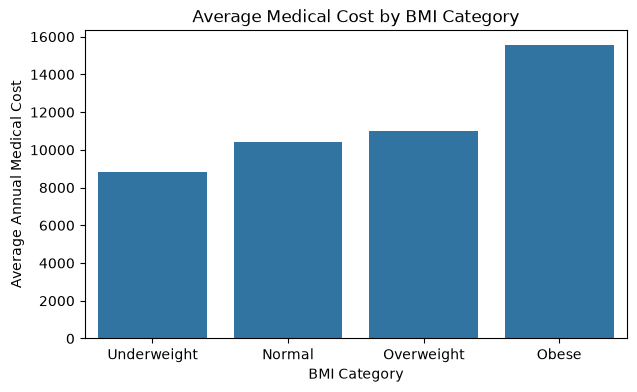

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))

sns.barplot(
    data=df,
    x="bmi_category",
    y="charges",
    estimator="mean",
    errorbar=None,
    order=["Underweight", "Normal", "Overweight", "Obese"]
)

plt.title("Average Medical Cost by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Annual Medical Cost")

plt.show()

#### Interpretation

The BMI segmentation reveals a clearer risk pattern than the simple correlation analysis.

- The majority of the portfolio is classified as **Obese (52.8%)**, followed by **Overweight (28.8%)**.
- Only a small proportion of members fall into the **Normal (16.8%)** and **Underweight (1.5%)** categories.

In terms of medical costs:
- **Obese members have the highest average annual medical cost (15,552.34)**.
- Overweight and Normal categories show lower and relatively similar cost levels.
- Underweight members have the lowest cost, but this group is very small and less statistically stable.

Overall, BMI shows a **non-linear relationship with medical costs**, which is not fully captured by the Pearson correlation (0.20).

#### Business Implication

BMI is a meaningful risk segmentation variable when used in categorical form rather than as a purely continuous measure.

From a portfolio management perspective:
- Obese members represent both the **largest group and the highest-cost segment**, making them a key driver of overall portfolio costs.
- Overweight members also contribute significantly due to their size.

This suggests that BMI-based segmentation could improve risk monitoring and help identify high-cost population clusters more effectively than linear assumptions.

### 7. Risk Segmentation (Combined Risk Profiles)

We now combine age, smoking status, and BMI category to create risk profiles.

This allows us to analyze medical costs at a more realistic portfolio level, where multiple risk factors interact rather than being evaluated independently.

In [29]:
df["risk_profile"] = (
    df["age_band"].astype(str) + " | " +
    df["smoker"] + " | " +
    df["bmi_category"]
)

df[["age_band", "smoker", "bmi_category", "risk_profile"]].head(10)

,age_band,smoker,bmi_category,risk_profile
0,18–29,yes,Overweight,18–29 | yes | Overweight
1,18–29,no,Obese,18–29 | no | Obese
2,18–29,no,Obese,18–29 | no | Obese
3,30–39,no,Normal,30–39 | no | Normal
4,30–39,no,Overweight,30–39 | no | Overweight
5,30–39,no,Overweight,30–39 | no | Overweight
6,40–49,no,Obese,40–49 | no | Obese
7,30–39,no,Overweight,30–39 | no | Overweight
8,30–39,no,Overweight,30–39 | no | Overweight
9,50–64,no,Overweight,50–64 | no | Overweight


### 7.1 Average Cost by Risk Profile

We now calculate the average annual medical cost for each combined risk profile.

This allows us to identify the most expensive customer segments in the portfolio and evaluate how multiple risk factors interact.

In [30]:
risk_profile_summary = df.groupby("risk_profile").agg(
    Members=("charges", "count"),
    Average_Cost=("charges", "mean")
).round(2)

risk_profile_summary.sort_values("Average_Cost", ascending=False).head(10)

,Members,Average_Cost
risk_profile,,
50–64 | yes | Obese,41,46973.11
40–49 | yes | Obese,30,42245.86
30–39 | yes | Obese,29,40634.63
18–29 | yes | Obese,45,36760.68
50–64 | yes | Overweight,16,27667.32
30–39 | yes | Underweight,2,25878.72
40–49 | yes | Overweight,18,25368.67
50–64 | yes | Normal,11,24210.26
40–49 | yes | Normal,14,21470.05


### 7.2 Interpretation — Risk Profile Analysis

The combined risk profile analysis reveals strong interaction effects between smoking status, age, and BMI.

Key findings:
- All highest-cost segments are composed exclusively of **smokers**.
- The most expensive segment (50–64 | smoker | obese) has an average annual cost of approximately **46,973**, which is more than **3.5× the portfolio average**.
- Age and BMI further amplify costs within the smoker population, with older and obese smokers representing the highest-cost groups.

This indicates that smoking acts as a primary risk separator in the portfolio, while age and BMI function as secondary amplifiers of risk within that group.

### 7.3 Business Implication

From a portfolio management perspective, smoking status is the most critical segmentation variable, as it creates a clear separation between low-cost and high-cost populations.

Age and BMI further refine risk differentiation within the smoker segment.

This suggests that effective risk management should prioritize:
- identification of smoker populations as the primary high-risk group,
- additional segmentation of smokers using age and BMI,
- monitoring of high-risk clusters such as older obese smokers for cost concentration.

### 8. Portfolio Risk Concentration

We now evaluate how medical costs are distributed across risk profiles.

The objective is to determine whether a small number of risk segments are responsible for a large proportion of total healthcare costs.

In [31]:
risk_concentration = df.groupby("risk_profile").agg(
    Members=("charges", "count"),
    Total_Cost=("charges", "sum"),
    Average_Cost=("charges", "mean")
).round(2)

risk_concentration.sort_values("Total_Cost", ascending=False).head(10)

,Members,Total_Cost,Average_Cost
risk_profile,,,
50–64 | no | Obese,193,2616627.51,13557.66
50–64 | yes | Obese,41,1925897.68,46973.11
18–29 | yes | Obese,45,1654230.78,36760.68
40–49 | yes | Obese,30,1267375.77,42245.86
30–39 | yes | Obese,29,1178404.30,40634.63
50–64 | no | Overweight,82,1104350.88,13467.69
40–49 | no | Obese,115,1038337.37,9029.02
18–29 | no | Obese,160,707684.10,4423.03
40–49 | no | Overweight,71,677509.20,9542.38


In [32]:
risk_concentration_sorted = risk_concentration.sort_values("Total_Cost", ascending=False)

top_10_percent_index = int(len(risk_concentration_sorted) * 0.1)

top_10_profiles = risk_concentration_sorted.head(top_10_percent_index)

top_10_cost_share = top_10_profiles["Total_Cost"].sum() / risk_concentration_sorted["Total_Cost"].sum()

print(f"Top 10% of risk profiles account for {top_10_cost_share:.2%} of total medical costs.")

Top 10% of risk profiles account for 25.58% of total medical costs.


### Interpretation — Risk Concentration

The analysis shows that the top 10% of risk profiles account for **25.58% of total medical costs**.

This indicates a **moderately concentrated risk structure**.

### Observations:

- Medical costs are **not evenly distributed** across the portfolio.
- A small number of high-risk profiles contribute disproportionately to total costs.
- However, the concentration is not extreme (e.g. 70–80%), suggesting that risk is spread across multiple segments rather than dominated by a single group.

### Additional insight:

The highest-cost profiles are consistently combinations of:
- **smoking status (yes)**
- **older age groups (40–64)**
- **high BMI (obese)**

Interestingly, some non-smoker obese groups still appear in high total cost rankings due to their larger population size, even though their average cost is lower than smoker groups.

### Business Implication

The portfolio exhibits a mixed risk structure where both:
- high-cost severity segments (e.g., smoker + obese + older),
- and high-volume segments (e.g., non-smoker + obese)

contribute significantly to total medical costs.

This suggests that effective risk management should not focus solely on extreme high-cost individuals, but also consider larger mid-risk populations that collectively drive substantial portfolio costs.

## 9. Risk Scoring Model

The original dataset does not include insurance premiums or predefined risk scores.

To simulate a simplified underwriting process, we create a rule-based risk scoring model using the strongest risk factors identified in the analysis:

- Smoking status
- Age band
- BMI category

Each risk factor is assigned points according to its observed impact on medical costs. The total score represents the member's overall risk level and forms the basis for later pricing simulations.

In [34]:
def calculate_risk_score(row):
    score = 0

    # Smoking
    if row["smoker"] == "yes":
        score += 3

    # Age
    if row["age_band"] == "40–49":
        score += 1
    elif row["age_band"] == "50–64":
        score += 2

    # BMI
    if row["bmi_category"] == "Overweight":
        score += 1
    elif row["bmi_category"] == "Obese":
        score += 2

    return score


df["risk_score"] = df.apply(calculate_risk_score, axis=1)

df[["age_band", "smoker", "bmi_category", "risk_score"]].head(10)

,age_band,smoker,bmi_category,risk_score
0,18–29,yes,Overweight,4
1,18–29,no,Obese,2
2,18–29,no,Obese,2
3,30–39,no,Normal,0
4,30–39,no,Overweight,1
5,30–39,no,Overweight,1
6,40–49,no,Obese,3
7,30–39,no,Overweight,1
8,30–39,no,Overweight,1
9,50–64,no,Overweight,3


### 9.1 Risk Score Distribution

Before defining risk tiers, we examine how members are distributed across the calculated risk scores.

This helps ensure that the final risk tiers are balanced, interpretable, and suitable for portfolio monitoring.

In [35]:
score_distribution = pd.DataFrame({
    "Members": df["risk_score"].value_counts().sort_index()
})

score_distribution["Percentage"] = (
    score_distribution["Members"] / len(df) * 100
).round(1)

score_distribution

,Members,Percentage
risk_score,,
0,117,8.7
1,190,14.2
2,367,27.4
3,227,17.0
4,247,18.5
5,103,7.7
6,46,3.4
7,41,3.1


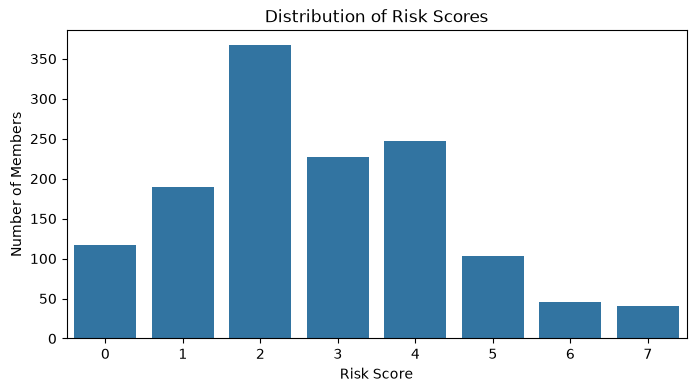

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.countplot(data=df, x="risk_score")

plt.title("Distribution of Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Members")

plt.show()

### 9.2 Risk Tier Classification

Based on the distribution of risk scores, members are classified into three risk tiers:

| Risk Score | Risk Tier |
|------------|-----------|
| 0–2 | Low |
| 3–4 | Medium |
| 5–7 | High |

The thresholds were selected after examining the score distribution to produce meaningful and interpretable portfolio segments rather than applying arbitrary cutoffs.

In [37]:
def risk_tier(score):
    if score <= 2:
        return "Low"
    elif score <= 4:
        return "Medium"
    else:
        return "High"

df["risk_tier"] = df["risk_score"].apply(risk_tier)

tier_summary = pd.DataFrame({
    "Members": df["risk_tier"].value_counts(),
    "Percentage": (
        df["risk_tier"].value_counts(normalize=True) * 100
    ).round(1)
})

tier_summary

,Members,Percentage
risk_tier,,
Low,674,50.4
Medium,474,35.4
High,190,14.2


### 9.3 Validation of the Risk Scoring Model

To evaluate the usefulness of the risk scoring model, we compare the average annual medical cost across the three risk tiers.

A well-designed risk score should produce progressively higher medical costs as risk increases.

In [38]:
risk_validation = df.groupby("risk_tier").agg(
    Members=("charges", "count"),
    Average_Annual_Cost=("charges", "mean")
).round(2)

risk_validation

,Members,Average_Annual_Cost
risk_tier,,
High,190,37850.18
Low,674,6253.33
Medium,474,13395.66


### Interpretation — Risk Score Validation

The rule-based risk scoring model successfully differentiates members into distinct cost groups.

Key findings:

- **Low-risk members** have an average annual medical cost of approximately **6,253**.
- **Medium-risk members** have an average annual medical cost of approximately **13,396**.
- **High-risk members** have an average annual medical cost of approximately **37,850**.

The steady increase in average cost across the three tiers indicates that the scoring model aligns well with the observed claims experience, despite being constructed solely from pre-policy characteristics (age, smoking status, and BMI).

This demonstrates that a simple, transparent scoring framework can effectively support risk segmentation and pricing decisions.

### Business Implication

The validated risk score provides a simple and explainable framework for classifying members before claims occur.

In practice, such a score could support:

- risk-based portfolio monitoring,
- underwriting and pricing decisions,
- identification of high-risk member segments,
- targeted health management or prevention programmes.

While simplified for this project, the approach illustrates how observable member characteristics can be translated into an actionable risk assessment process.

## 10. Simulated Pricing Framework

The dataset does not contain premium information.

To demonstrate a simplified pricing process, we estimate expected annual medical costs for each risk tier using historical portfolio experience.

A 20% loading is then applied to represent administrative expenses, capital requirements, and target profit.

This pricing framework is intended for illustration only and does not represent a production insurance pricing model.

In [39]:
pricing_table = (
    df.groupby("risk_tier")
      .agg(Expected_Annual_Cost=("charges", "mean"))
      .round(2)
)

pricing_table["Simulated_Premium"] = (
    pricing_table["Expected_Annual_Cost"] * 1.20
).round(2)

pricing_table["Loading"] = "20%"

pricing_table

,Expected_Annual_Cost,Simulated_Premium,Loading
risk_tier,,,
High,37850.18,45420.22,20%
Low,6253.33,7504.00,20%
Medium,13395.66,16074.79,20%


## 11. Project Limitations

While this analysis provides useful insights into health insurance risk drivers and portfolio segmentation, several limitations should be acknowledged.

These limitations help clarify the scope of the conclusions and highlight areas for future improvement.

### Limitations

- **Cross-sectional data only**  
  The dataset represents a single snapshot in time. It does not include longitudinal or time-series information, so we cannot analyze how risk evolves over time.

- **No claim-level detail**  
  The dataset provides annual medical costs but does not include individual claim frequency or medical event breakdowns, limiting actuarial depth.

- **No premium information**  
  Insurance premiums are not provided, so profitability and underwriting margins are simulated rather than observed.

- **Simplified risk model**  
  The risk scoring model is rule-based and constructed from observed trends rather than statistically optimized or machine-learned.

- **Correlation ≠ causation**  
  The analysis identifies associations between variables and medical costs but does not establish causal relationships.

## 12. Business Recommendations

Based on the findings of this analysis, several recommendations can be made for health insurance portfolio management and pricing strategy.

### 1. Strengthen Smoking-Based Segmentation

Smoking status is the strongest driver of medical costs in the portfolio, with smokers incurring significantly higher average expenses.

It should remain a primary variable in underwriting and pricing decisions.

### 2. Use Age Bands for Portfolio Monitoring

Medical costs increase consistently with age. 
Age bands provide a stable and interpretable way to monitor portfolio risk evolution over time.

### 3. Incorporate BMI Categories in Risk Assessment

BMI shows a non-linear relationship with medical costs. Using BMI categories rather than continuous values improves interpretability and segmentation quality.

### 4. Monitor High-Risk Combined Profiles

Combined risk profiles (e.g., older smokers with high BMI) represent a disproportionate share of total costs and should be monitored closely for portfolio concentration risk.

### 5. Develop Data Infrastructure for Advanced Modeling

Future improvements should include:
- premium data
- claim frequency and severity
- longitudinal patient records

This would enable more advanced actuarial models such as GLMs or machine learning-based pricing models.

In [40]:
df.groupby("smoker")["charges"].agg(["mean", "median", "min", "max", "count"])

,mean,median,min,max,count
smoker,,,,,
no,8434.268298,7345.40530,1121.8739,36910.60803,1064
yes,32050.231832,34456.34845,12829.4551,63770.42801,274
